In [1]:
%matplotlib inline
import os, json, warnings
import numpy as np
import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
import corner
from matplotlib.lines import Line2D
from enterprise_extensions import model_utils

# publication settings
mpl.rcParams.update({
    "figure.dpi"        : 120,
    "savefig.dpi"       : 300,
    "savefig.bbox"      : "tight",
    "savefig.pad_inches": 0.02,
    "pdf.fonttype"      : 42,     # embed as TrueType, no Type 3, journals require this
    "ps.fonttype"       : 42,
    "font.family"       : "serif",
    "font.serif"        : ["DejaVu Serif"],
    "mathtext.fontset"  : "dejavuserif",
    "font.size"         : 11,
    "axes.labelsize"    : 13,
    "axes.titlesize"    : 13,
    "xtick.labelsize"   : 10,
    "ytick.labelsize"   : 10,
    "axes.linewidth"    : 0.9,
    "xtick.direction"   : "in",
    "ytick.direction"   : "in",
    "xtick.top"         : True,
    "ytick.right"       : True,
    "xtick.major.width" : 0.9,
    "ytick.major.width" : 0.9,
    "xtick.major.size"  : 4.0,
    "ytick.major.size"  : 4.0,
    "lines.linewidth"   : 1.2,
    "legend.frameon"    : False,
})

H5  = "/scratch/na00078/projects/IPTA_MDC2/h5_files/"
OUT = "/scratch/na00078/projects/IPTA_MDC2/post_processing/"

target_d_L     = 75.4
eta_tol        = 0.01
megaparsec     = 3.086e+22
speed_of_light = 299792458.0
T_sun          = 1.327124400e20 / speed_of_light**3

COL_F, COL_H, COL_MC = 3, 4, 5      # log10 fGW, log10 h0, log10 Mc
LOG10_H_MAX = -11.0                 # upper edge of the Uniform(-18, -11) prior

C_PRE, C_POST = "#4477AA", "#CC6677"
SHOW_LEGEND = False                 # draft figure has no legend, set True if you want one

RUNS = {
    "broad": dict(
        unmasked = H5 + "G2D2_broad_detect_tref_4core_UNMASKED_outfile.h5",
        raw      = H5 + "G2D2_broad_detect_tref_4core.h5",
        base     = "IPTA_MDC2_G2D2_broad_detection_dL_75.4_4core_",
        FIXED    = False,
    ),
    "fixed": dict(
        unmasked = H5 + "G2D2_narrow_detect_tref_4core_UNMASKED_outfile.h5",
        raw      = H5 + "G2D2_narrow_detect_tref_4core.h5",
        base     = "IPTA_MDC2_G2D2_narrow_detection_dL_75.4_4core_",
        FIXED    = True,
    ),
}

res = {}
for t, c in RUNS.items():
    print(t, "unmasked outfile present:", os.path.exists(c["unmasked"]))

broad unmasked outfile present: True
fixed unmasked outfile present: True


In [2]:
CHUNK = 2_000_000

def load_cols(cfg):
    """(N, 8) float32 array of the first 8 cold chain parameters, pre mask."""
    if os.path.exists(cfg["unmasked"]):
        print("reading unmasked outfile", os.path.basename(cfg["unmasked"]), flush=True)
        with h5py.File(cfg["unmasked"], "r") as h:
            return h["samples_cold"][0, :, :8].astype(np.float32)
    print("no unmasked outfile, reading raw run file in chunks", flush=True)
    with h5py.File(cfg["raw"], "r") as h:
        d = h["samples_cold"]
        N = d.shape[1]
        out = np.empty((N, 8), dtype=np.float32)
        for a in range(0, N, CHUNK):
            b = min(a + CHUNK, N)
            out[a:b] = d[0, a:b, :8]
            print("  ", b, "/", N, flush=True)
    return out

def dL_mask_indices(sc):
    """1 percent dL window around target_d_L, dL from draft Equation 2."""
    h_amp = 10.0 ** sc[:, COL_H].astype(np.float64)
    fff   = 10.0 ** sc[:, COL_F].astype(np.float64)
    mmm   = 10.0 ** sc[:, COL_MC].astype(np.float64)
    dL = 2 * (mmm * T_sun) ** (5 / 3) * (np.pi * fff) ** (2 / 3) / h_amp \
         * speed_of_light / megaparsec
    del h_amp, fff, mmm
    lo, hi = target_d_L * (1 - eta_tol), target_d_L * (1 + eta_tol)
    idx = np.where((dL >= lo) & (dL <= hi))[0]
    del dL
    return idx, lo, hi

def sd_bf(samples):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return model_utils.bayes_fac(samples=samples, logAmax=LOG10_H_MAX)

print("helpers ready")

helpers ready


In [3]:
def analyse(tag, thin_pre_plot=100, show=True, save=True):
    cfg = RUNS[tag]
    print("=" * 26, tag, flush=True)

    sc = load_cols(cfg)
    N = sc.shape[0]
    idx, lo, hi = dL_mask_indices(sc)
    print("pre mask N        ", N, flush=True)
    print("dL window         %.3f to %.3f Mpc" % (lo, hi), flush=True)
    print("post mask N       ", len(idx), flush=True)

    c = sc[:, COL_H]
    b_t, e_t = sd_bf(c[::10])
    b_f, e_f = sd_bf(c)
    b_p, e_p = sd_bf(c[idx])
    print("B10 pre  [::10]   ", b_t, "+/-", e_t, flush=True)
    print("B10 pre  full 1e8 ", b_f, "+/-", e_f, flush=True)
    print("B10 post mask     ", b_p, "+/-", e_p, flush=True)

    res[tag] = dict(N=int(N), after_mask=int(len(idx)),
                    pre_mask_thin10=[float(b_t), float(e_t)],
                    pre_mask_full=[float(b_f), float(e_f)],
                    post_mask=[float(b_p), float(e_p)])

    FIXED  = cfg["FIXED"]
    cols   = [COL_MC, COL_H] if FIXED else [COL_MC, COL_H, COL_F]
    labels = [r"$\log_{10}\mathcal{M}_{c}\,[M_{\odot}]$", r"$\log_{10} h_{0}$"]
    truths = [np.log10(4.3e9), -13.67]
    rng    = [(7.0, 10.3), (-15.0, -12.5)]
    if not FIXED:
        labels += [r"$\log_{10} f_{\rm GW}\,[{\rm Hz}]$"]
        truths += [-8.43]
        rng    += [(-8.8, -7.2)]

    pre  = sc[::thin_pre_plot][:, cols]
    post = sc[idx][:, cols]
    print("plotting pre", pre.shape, "post", post.shape, flush=True)

    sig    = np.array([0.5, 1.0, 1.5, 2.0])
    levels = 1.0 - np.exp(-0.5 * sig ** 2)
    side   = 2.35 if FIXED else 2.15
    base_kw = dict(labels=labels, range=rng, bins=30, smooth=1.0, levels=levels,
                   plot_datapoints=False, plot_density=False,
                   no_fill_contours=True, fill_contours=False,
                   label_kwargs={"fontsize": 13},
                   max_n_ticks=4, use_math_text=True)

    fig = corner.corner(pre, color=C_PRE,
                        hist_kwargs={"density": True, "color": C_PRE, "lw": 1.3},
                        **base_kw)
    fig.set_size_inches(side * len(cols), side * len(cols))
    corner.corner(post, fig=fig, color=C_POST, truths=truths, truth_color="k",
                  hist_kwargs={"density": True, "color": C_POST, "lw": 1.3},
                  **base_kw)

    for ax in fig.get_axes():
        ax.tick_params(which="both", direction="in", top=True, right=True)
        ax.xaxis.set_label_coords(0.5, -0.32)
        ax.yaxis.set_label_coords(-0.35, 0.5)

    if SHOW_LEGEND:
        handles = [Line2D([], [], color=C_PRE,  lw=1.6, label="before $d_{L}$ mask"),
                   Line2D([], [], color=C_POST, lw=1.6, label="after $d_{L}$ mask"),
                   Line2D([], [], color="k",    lw=1.2, label="injected")]
        fig.legend(handles=handles, loc="upper right",
                   bbox_to_anchor=(0.98, 0.98), fontsize=11)

    fig.subplots_adjust(wspace=0.06, hspace=0.06)

    if save:
        stem = OUT + cfg["base"] + "fig1_mask_effect"
        fig.savefig(stem + ".pdf")
        fig.savefig(stem + ".png")
        print("saved", os.path.basename(stem) + ".pdf and .png", flush=True)

    plt.show() if show else plt.close(fig)
    del sc, pre, post, c
    return res[tag]

print("analyse ready")

analyse ready


========================== broad
reading unmasked outfile G2D2_broad_detect_tref_4core_UNMASKED_outfile.h5
pre mask N         100000000
dL window         74.646 to 76.154 Mpc
post mask N        192343
B10 pre  [::10]    193.11127745385636 +/- 2.144641642859474
B10 pre  full 1e8  190.31394545672094 +/- 0.9299017166158737
B10 post mask      nan +/- nan
plotting pre (1000000, 3) post (192343, 3)
saved IPTA_MDC2_G2D2_broad_detection_dL_75.4_4core_fig1_mask_effect.pdf and .png


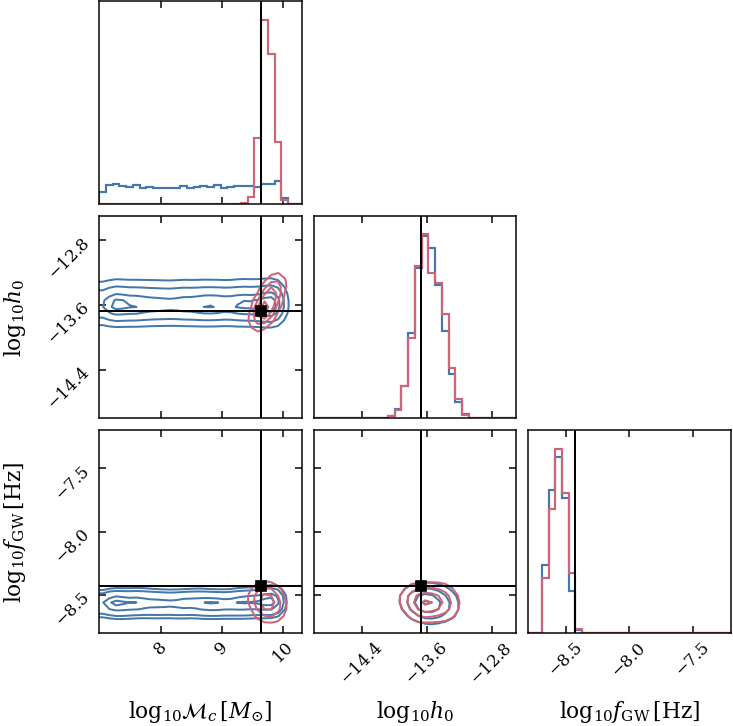

========================== fixed
reading unmasked outfile G2D2_narrow_detect_tref_4core_UNMASKED_outfile.h5
pre mask N         100000000
dL window         74.646 to 76.154 Mpc
post mask N        239483
B10 pre  [::10]    1.601755090865904e+02 +/- 2.3925159959265936
B10 pre  full 1e8  167.41627158178326 +/- 1.5145701812340004
B10 post mask      nan +/- nan
plotting pre (1000000, 2) post (239483, 2)
saved IPTA_MDC2_G2D2_narrow_detection_dL_75.4_4core_fig1_mask_effect.pdf and .png


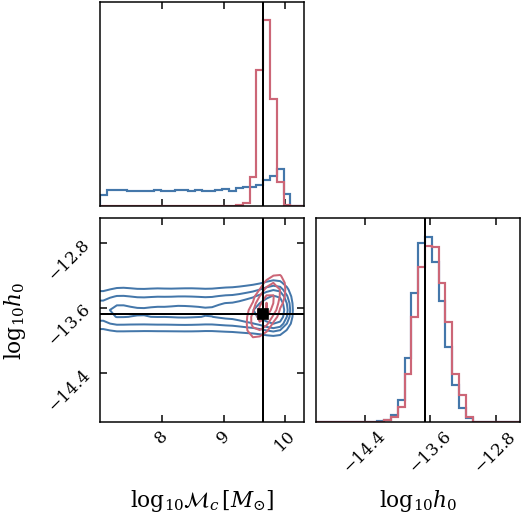

In [4]:
_ = analyse("broad")
_ = analyse("fixed")

In [5]:
json.dump(res, open(OUT + "fig1_4core_values.json", "w"), indent=2)

def f(p):
    return "nan" if not np.isfinite(p[0]) else "%.4f +/- %.4f" % (p[0], p[1])

hdr = "%-7s %12s %12s %22s %22s %22s" % ("run", "pre mask N", "post mask N",
      "B10 pre [::10]", "B10 pre full", "B10 post mask")
print(hdr); print("-" * len(hdr))
for tag in ["broad", "fixed"]:
    if tag in res:
        r = res[tag]
        print("%-7s %12d %12d %22s %22s %22s" % (tag, r["N"], r["after_mask"],
              f(r["pre_mask_thin10"]), f(r["pre_mask_full"]), f(r["post_mask"])))
print()
print("nan post mask means no bin above the log10 h0 prior floor held enough")
print("retained samples for the estimator to average, it is not an infinity")

run       pre mask N  post mask N         B10 pre [::10]           B10 pre full          B10 post mask
------------------------------------------------------------------------------------------------------
broad      100000000       192343    193.1113 +/- 2.1446    190.3139 +/- 0.9299                    nan
fixed      100000000       239483    160.1755 +/- 2.3925    167.4163 +/- 1.5146                    nan

nan post mask means no bin above the log10 h0 prior floor held enough
retained samples for the estimator to average, it is not an infinity


In [6]:
import h5py, numpy as np
from enterprise_extensions import model_utils

H5 = '/scratch/na00078/projects/IPTA_MDC2/h5_files/'

files = [('old broad', 'G2D2_broad_detect_no_tref_17_Dec_2025_outfile.h5'),
         ('old fixed', 'G2D2_narrow_detect_outfile.h5')]

for tag, f in files:
    with h5py.File(H5 + f, 'r') as h:
        c = h['samples_cold'][0, :, 4]
    b10, e10 = model_utils.bayes_fac(samples=c[::10], logAmax=-11)
    bf, ef = model_utils.bayes_fac(samples=c, logAmax=-11)
    print(f'{tag}  N {len(c)}')
    print(f'{tag}  thin10   {b10:.4f} +/- {e10:.4f}')
    print(f'{tag}  full     {bf:.4f} +/- {ef:.4f}')
    print()

old broad  N 100000000
old broad  thin10   331.4852 +/- 3.8035
old broad  full     326.7339 +/- 4.7413

old fixed  N 100000000
old fixed  thin10   209.4529 +/- 3.5302
old fixed  full     236.0413 +/- 1.6848

